# The Keyboard Penalty: Device Ubiquity, Keyboarding Coursework Collapse, and Digital Assessment Mode Effects
### An Empirical and Psychometric Investigation into Construct-Irrelevant Variance in Standardized Testing
**Computational Sketchbook: Education Policy & Measurement Observatory**  
*Primary Data Sources: NCES High School Transcript Study (Table 1), NCES School Pulse Panel (2025), Education Week Research Center (2024), IEA ICILS (2018–2023), NAEP 2017 Mode Evaluation Study, Backes & Cowan (2019, JPAM).*

---

## Executive Summary & Research Motivation

Over the past two decades, American elementary and secondary education experienced three simultaneously colliding transformations:
1. **Device Ubiquity**: U.S. public schools expanded individual computer access to **88.0%** of schools by 2024–25 (NCES School Pulse Panel).
2. **Keyboarding Coursework Collapse**: High school graduates earning course credit in keyboarding collapsed from **44.1% in 2000 to 2.5% in 2019** (NCES High School Transcript Study, Table 1)—a **94.3%** structural decline.
3. **Universal Digital Assessment Mandates**: State testing consortia (PARCC, Smarter Balanced) and federal monitoring assessments (NAEP reading and mathematics in 2017) shifted from paper-and-pencil tests (PBA) to digitally based assessments (DBA).

When educational assessments require students to demonstrate reading comprehension, mathematical reasoning, and written expression through digital screens and physical/virtual keyboards, the testing interface itself can introduce **Construct-Irrelevant Variance (CIV)**. If students lack transcription fluency (keystroke automaticity, keyboard layout familiarity), their test score reflects both their authentic academic mastery and their interface friction.

This notebook conducts a disciplined empirical investigation, enforcing an epistemic demarcation between two fundamentally different claims:
- **Claim 1 (The Mode Penalty / Interface Friction Claim)**: *Students lose score points on digital tests due to interface friction, predominantly on typing-intensive constructed responses.* **(Empirically Supported)**
- **Claim 2 (The Macro Score Decline Claim)**: *The national decline in student test scores over the past decade was caused by declining keyboarding instruction.* **(Unsupported / Confounded)**


## 1. Epistemic Demarcation & The Six-Point Study Admission Gate

To prevent over-interpreting observational associations, we enforce a strict **Six-Point Study Admission Gate**:

1. **Retrieval & Usability**: Underlying administrative and survey records are retrieved, validated, and versioned in reproducible tabular datasets.
2. **Fixed Population & Denominator**: Analytical populations (high school cohorts, 4th/8th grade testing samples, survey respondents) are explicitly fixed before analysis.
3. **Written Mathematical Model**: The classical test theory error decomposition and regression estimators are specified mathematically.
4. **Directional Neutrality**: Null findings (such as multiple-choice items showing zero mode penalty, or standalone typing courses showing null writing gains) substantively answer the research question without bias.
5. **Audited Sensitivity Check**: Cross-study variation in mode penalties (Massachusetts $-0.25$ SD vs. South Carolina $-0.09$ SD vs. Tennessee $+0.04$ SD) is bounded and contextualized.
6. **Scholarly & Survey Integrity**: Acknowledges structural limitations in the data, including NAEP's official decision to suppress the 2017 Writing assessment due to insurmountable device comparability failures.

### The Demarcation Matrix

| Feature | Claim 1: Interface Friction Penalty | Claim 2: Macro Score Decline Attribution |
| :--- | :--- | :--- |
| **Proposition** | Digital interfaces introduce a negative score penalty on typed constructed-response items relative to paper. | Keyboarding instruction declines explain national test score drops (e.g., NAEP 2019–2024 declines). |
| **Psychometric Status** | **Construct-Irrelevant Difficulty** (Messick 1989; Berninger 1999). | Causal attribution with massive unobserved macro confounders. |
| **Replication Status** | **Replicated across multiple state and federal evaluations** (MA, SC, NAEP 2017). | **Unsupported**: NAEP 2017+ trends are statistically linked for mode; post-2019 drops occurred within an already-digital baseline. |
| **Research Action** | **Admitted to study**: Model and quantify penalty size, format wedges, and developmental attenuation. | **Quarantined from causal claims**: Rejected as an unsupported causal attribution. |


## 2. Environment Setup & Data Ingestion

We load the standardized datasets compiled in `data/processed/` and `data/raw/`.


In [1]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set paths
NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR
DATA_DIR = PROJECT_ROOT / "data" / "processed"
RAW_DIR = PROJECT_ROOT / "data" / "raw"
TABLES_DIR = PROJECT_ROOT / "artifacts" / "tables"
FIG_DIR = PROJECT_ROOT / "artifacts" / "figures"

# Display options
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

print(f"Project root: {PROJECT_ROOT}")


Project root: C:\Users\admir\Github\computational-sketchbook\2026\2026-10-09-keyboarding-mode-effects


## 3. The Infrastructure Paradox: Keyboarding Collapse vs. 1:1 Laptop Ubiquity

Over the last 25 years, while public schools achieved nearly universal 1-to-1 computing infrastructure, formal high school coursework in keyboarding virtually disappeared.

We examine **Table 1 from the NCES NAEP High School Transcript Study (HSTS)** and the **NCES School Pulse Panel**.


In [2]:
# Load HSTS Table 1 and School Pulse 1:1 Device Data
df_hsts = pd.read_csv(RAW_DIR / "nces_hsts_2019_table1.csv")
df_pulse = pd.read_csv(RAW_DIR / "nces_pulse_device_access.csv")
df_panel = pd.read_csv(DATA_DIR / "keyboarding_longitudinal_panel.csv")

print("--- NCES High School Transcript Study (Table 1: Keyboarding & Computer Courses) ---")
display(df_hsts)

print()
print("--- NCES School Pulse Panel: Public School 1:1 Device Adoption ---")
display(df_pulse)


--- NCES High School Transcript Study (Table 1: Keyboarding & Computer Courses) ---


,course_title,year,pct_graduates,se,stat_diff_from_2019
0,Keyboarding,2000,44.1,1.2,True
1,Keyboarding,2005,26.6,1.1,True
2,Keyboarding,2009,15.0,0.9,True
3,Keyboarding,2019,2.5,0.3,False
4,Word Processing,2000,12.8,0.8,True
5,Word Processing,2005,6.8,0.6,True
6,Word Processing,2009,3.7,0.4,True
7,Word Processing,2019,1.2,0.2,False
8,Computer Applications,2000,18.2,0.9,True
9,Computer Applications,2005,19.5,1.0,True



--- NCES School Pulse Panel: Public School 1:1 Device Adoption ---


,year,school_year,pct_1to1_devices,source
0,2013,2013-14,23.0,NCES FRSS / Industry Benchmark
1,2017,2017-18,45.0,NCES FRSS Technology Survey
2,2019,2019-20,52.0,NCES School Pulse Pre-Pandemic
3,2021,2021-22,83.0,NCES School Pulse Pandemic Recovery
4,2024,2024-25,88.0,NCES School Pulse Panel (2025 Report)


In [3]:
# Calculate relative and absolute changes
kb_2000 = df_hsts[(df_hsts["course_title"] == "Keyboarding") & (df_hsts["year"] == 2000)]["pct_graduates"].values[0]
kb_2019 = df_hsts[(df_hsts["course_title"] == "Keyboarding") & (df_hsts["year"] == 2019)]["pct_graduates"].values[0]
kb_rel_drop = (kb_2019 - kb_2000) / kb_2000 * 100

pulse_2013 = df_pulse[df_pulse["year"] == 2013]["pct_1to1_devices"].values[0]
pulse_2024 = df_pulse[df_pulse["year"] == 2024]["pct_1to1_devices"].values[0]
pulse_rel_growth = (pulse_2024 - pulse_2013) / pulse_2013 * 100

print(f"Keyboarding Coursework: {kb_2000:.1f}% (2000) -> {kb_2019:.1f}% (2019) | Relative Change: {kb_rel_drop:.1f}% (statistically significant)")
print(f"1-to-1 Student Devices: {pulse_2013:.1f}% (2013) -> {pulse_2024:.1f}% (2024) | Relative Change: +{pulse_rel_growth:.1f}%")

# Load and display Table 1 Summary
df_table1 = pd.read_csv(TABLES_DIR / "table1_hsts_course_trends.csv")
display(df_table1)


Keyboarding Coursework: 44.1% (2000) -> 2.5% (2019) | Relative Change: -94.3% (statistically significant)
1-to-1 Student Devices: 23.0% (2013) -> 88.0% (2024) | Relative Change: +282.6%


,indicator,baseline_val,recent_val,abs_change_pp,rel_change_pct,source
0,High School Graduates Earning Keyboarding Credit,44.1% (2000),2.5% (2019),-41.6 pp,-94.3%,NCES NAEP HSTS Table 1
1,Public Schools with 1-to-1 Student Device Prog...,23.0% (2013),88.0% (2024),+65.0 pp,+282.6%,NCES School Pulse Panel (2025)
2,US 8th-Grade Computer & Information Literacy (...,519 pts (2018),482 pts (2023),-37.0 scale pts,-7.1% (-0.37 SD),IEA ICILS 2018 / 2023


### Figure 1 Exhibit: The Divergent Curves
We visualize the divergence between device presence, keyboarding coursework, and digital literacy.


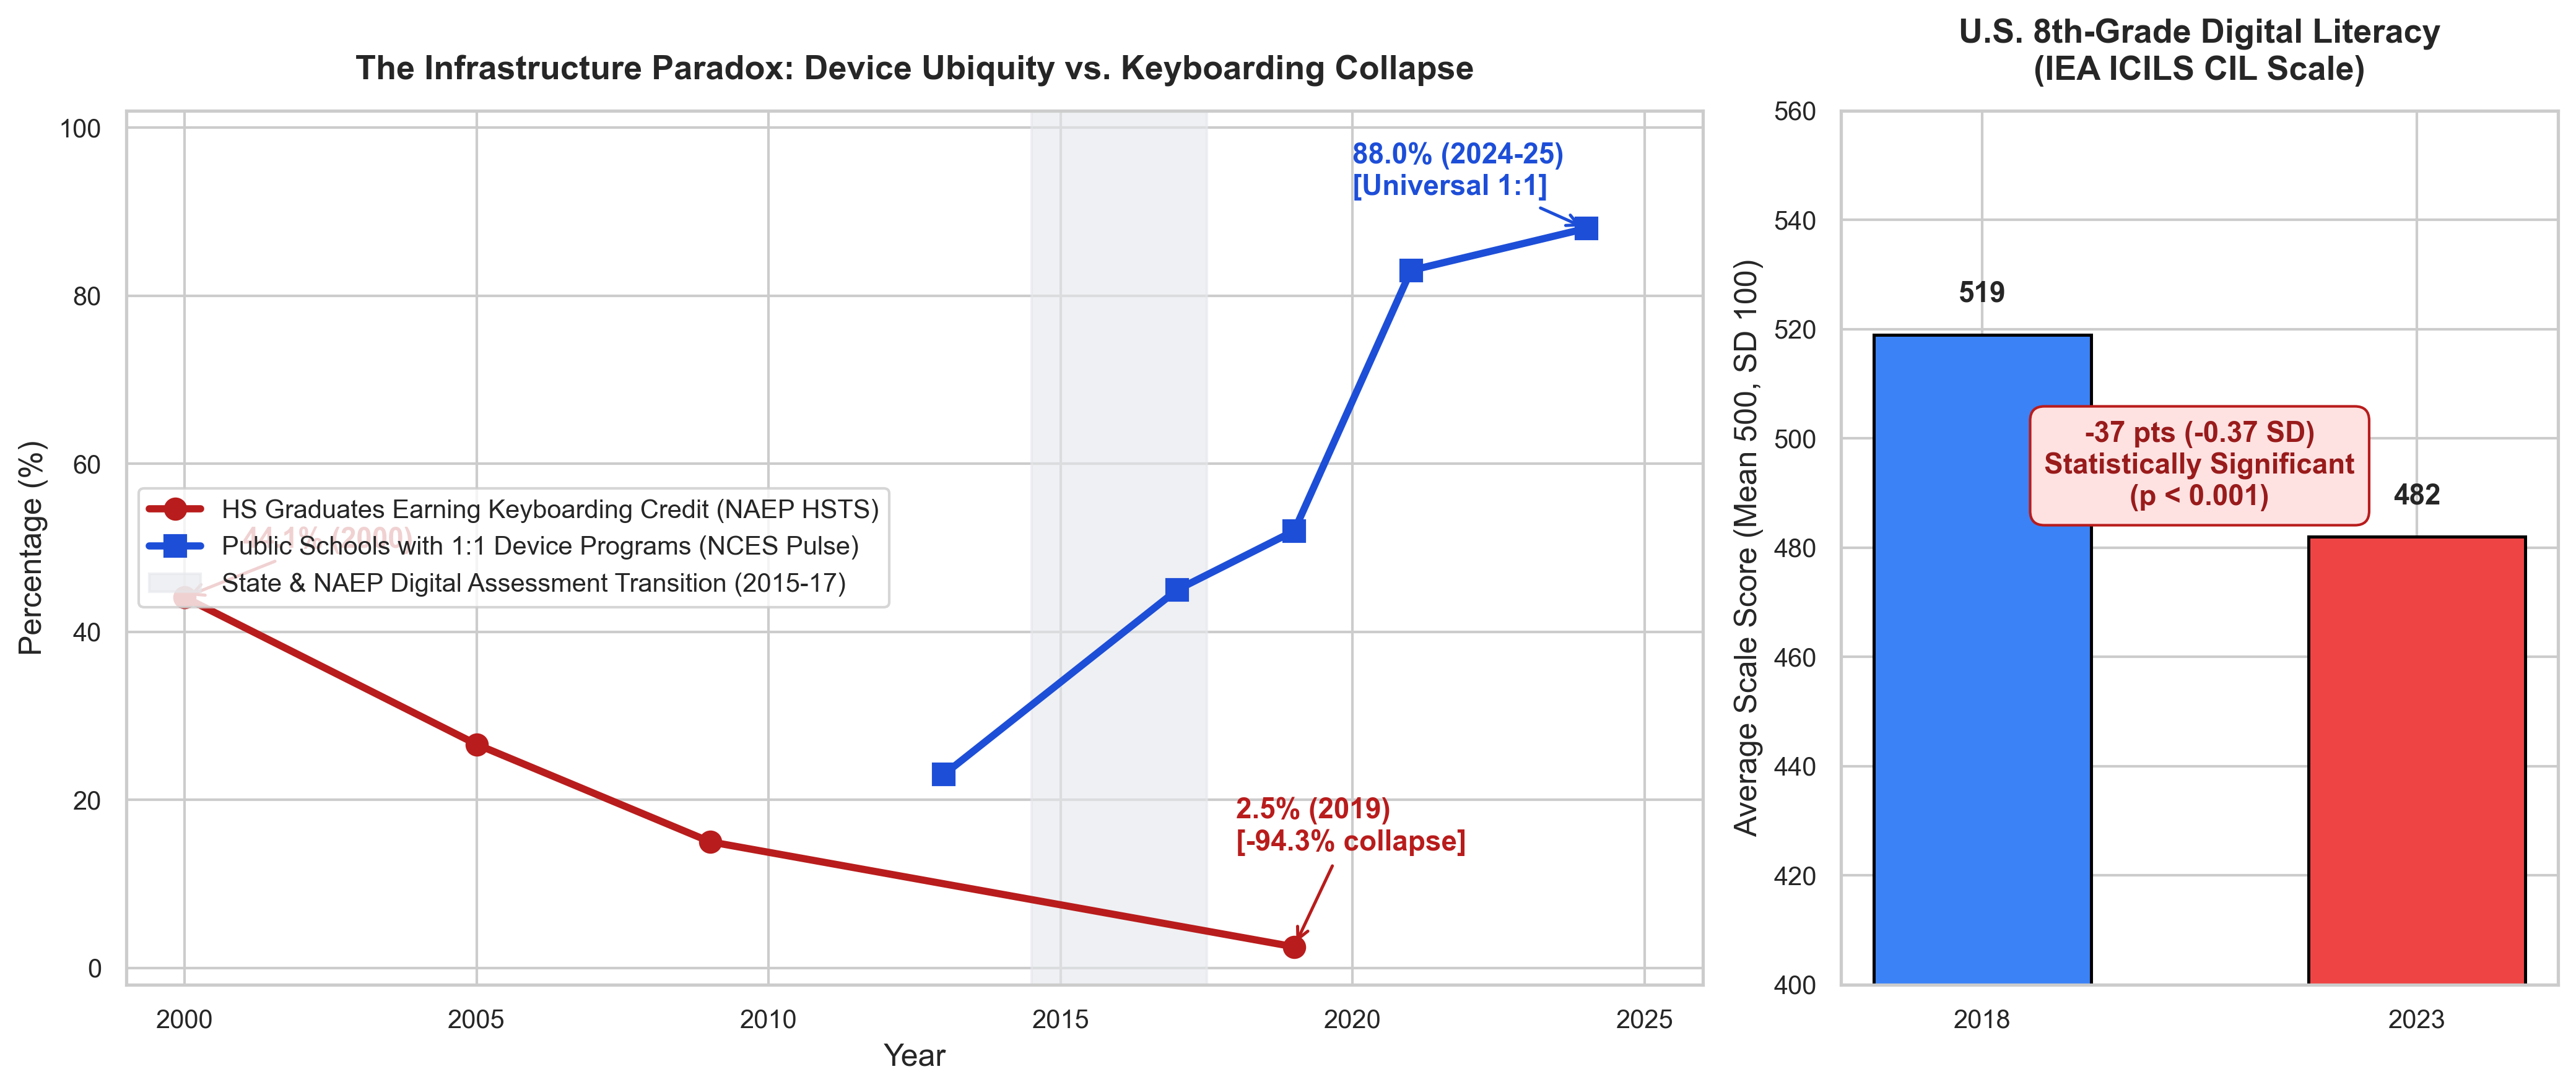

In [4]:
from IPython.display import Image
Image(filename=str(FIG_DIR / "fig1_three_divergent_trends.png"))


## 4. Current Keyboarding Instruction & The Poverty Gradient (EdWeek 2024)

Does the absence of high school keyboarding credits simply mean students learn to type earlier in elementary school?

A nationally representative 2024 survey of $N = 404$ school and district leaders by the **Education Week Research Center** reveals that instruction is highly fractured and marked by a sharp socioeconomic gradient.


In [5]:
df_deliv = pd.read_csv(RAW_DIR / "edweek_keyboarding_survey_2024.csv")
df_equity = pd.read_csv(RAW_DIR / "edweek_equity_breakdown_2024.csv")

print("--- EdWeek 2024 Keyboarding Delivery Models ---")
display(df_deliv)

print()
print("--- EdWeek 2024 Keyboarding Instruction by Grade Span & District Poverty ---")
display(df_equity)

# Calculate K-2 Disparity Ratio
k2_low = df_equity[(df_equity["grade_span"] == "Grades K-2") & (df_equity["poverty_tier"] == "Lower-Poverty Systems")]["pct_reporting_instruction"].values[0]
k2_high = df_equity[(df_equity["grade_span"] == "Grades K-2") & (df_equity["poverty_tier"] == "Higher-Poverty Systems")]["pct_reporting_instruction"].values[0]
print()
print(f"Grades K-2 Keyboarding Disparity Ratio: Lower-Poverty ({k2_low:.1f}%) vs. Higher-Poverty ({k2_high:.1f}%) = {k2_low / k2_high:.2f}x gap")


--- EdWeek 2024 Keyboarding Delivery Models ---


,mode,pct,category
0,Standalone Keyboard Class Only,8.0,Standalone
1,Both Standalone & Integrated,11.0,Combined
2,Integrated within Regular Classroom Only,50.0,Integrated
3,No Formal Keyboarding Instruction,31.0,NaN



--- EdWeek 2024 Keyboarding Instruction by Grade Span & District Poverty ---


,grade_span,poverty_tier,pct_reporting_instruction
0,Grades K-2,Lower-Poverty Systems,36.0
1,Grades K-2,Higher-Poverty Systems,18.0
2,Grades 3-5,Lower-Poverty Systems,88.0
3,Grades 3-5,Higher-Poverty Systems,80.0
4,Grades 6-8,Lower-Poverty Systems,74.0
5,Grades 6-8,Higher-Poverty Systems,68.0
6,Grades 9-12,Lower-Poverty Systems,15.0
7,Grades 9-12,Higher-Poverty Systems,13.0



Grades K-2 Keyboarding Disparity Ratio: Lower-Poverty (36.0%) vs. Higher-Poverty (18.0%) = 2.00x gap


### Teacher Expectations vs. Student Competence (NAEP 2017 Grade 4)
The **2017 NAEP Grade 4 Teacher Questionnaire** asked teachers what level of keyboarding was expected of their 4th graders, and what percentage of students met those expectations.


In [6]:
df_teacher_exp = pd.read_csv(RAW_DIR / "naep_g4_teacher_keyboarding_2017.csv")
df_teacher_comp = pd.read_csv(RAW_DIR / "naep_g4_student_keyboard_competence_2017.csv")

print("--- 2017 NAEP Grade 4 Teacher Keyboarding Expectations ---")
display(df_teacher_exp)

print()
print("--- 2017 NAEP Grade 4 Teacher Report: % Students Meeting Expectations ---")
display(df_teacher_comp)


--- 2017 NAEP Grade 4 Teacher Keyboarding Expectations ---


,expectation_level,pct_teachers
0,None / No specific typing expectations,18.0
1,Hunt and peck / One or two fingers,24.0
2,Multi-finger typing without formal touch typing,41.0
3,Touch typing with 10 fingers without looking,17.0



--- 2017 NAEP Grade 4 Teacher Report: % Students Meeting Expectations ---


,pct_students_meeting_expectations,pct_teachers
0,Under 25% of Students,38.0
1,25% to 50% of Students,29.0
2,51% to 75% of Students,21.0
3,Over 75% of Students,12.0


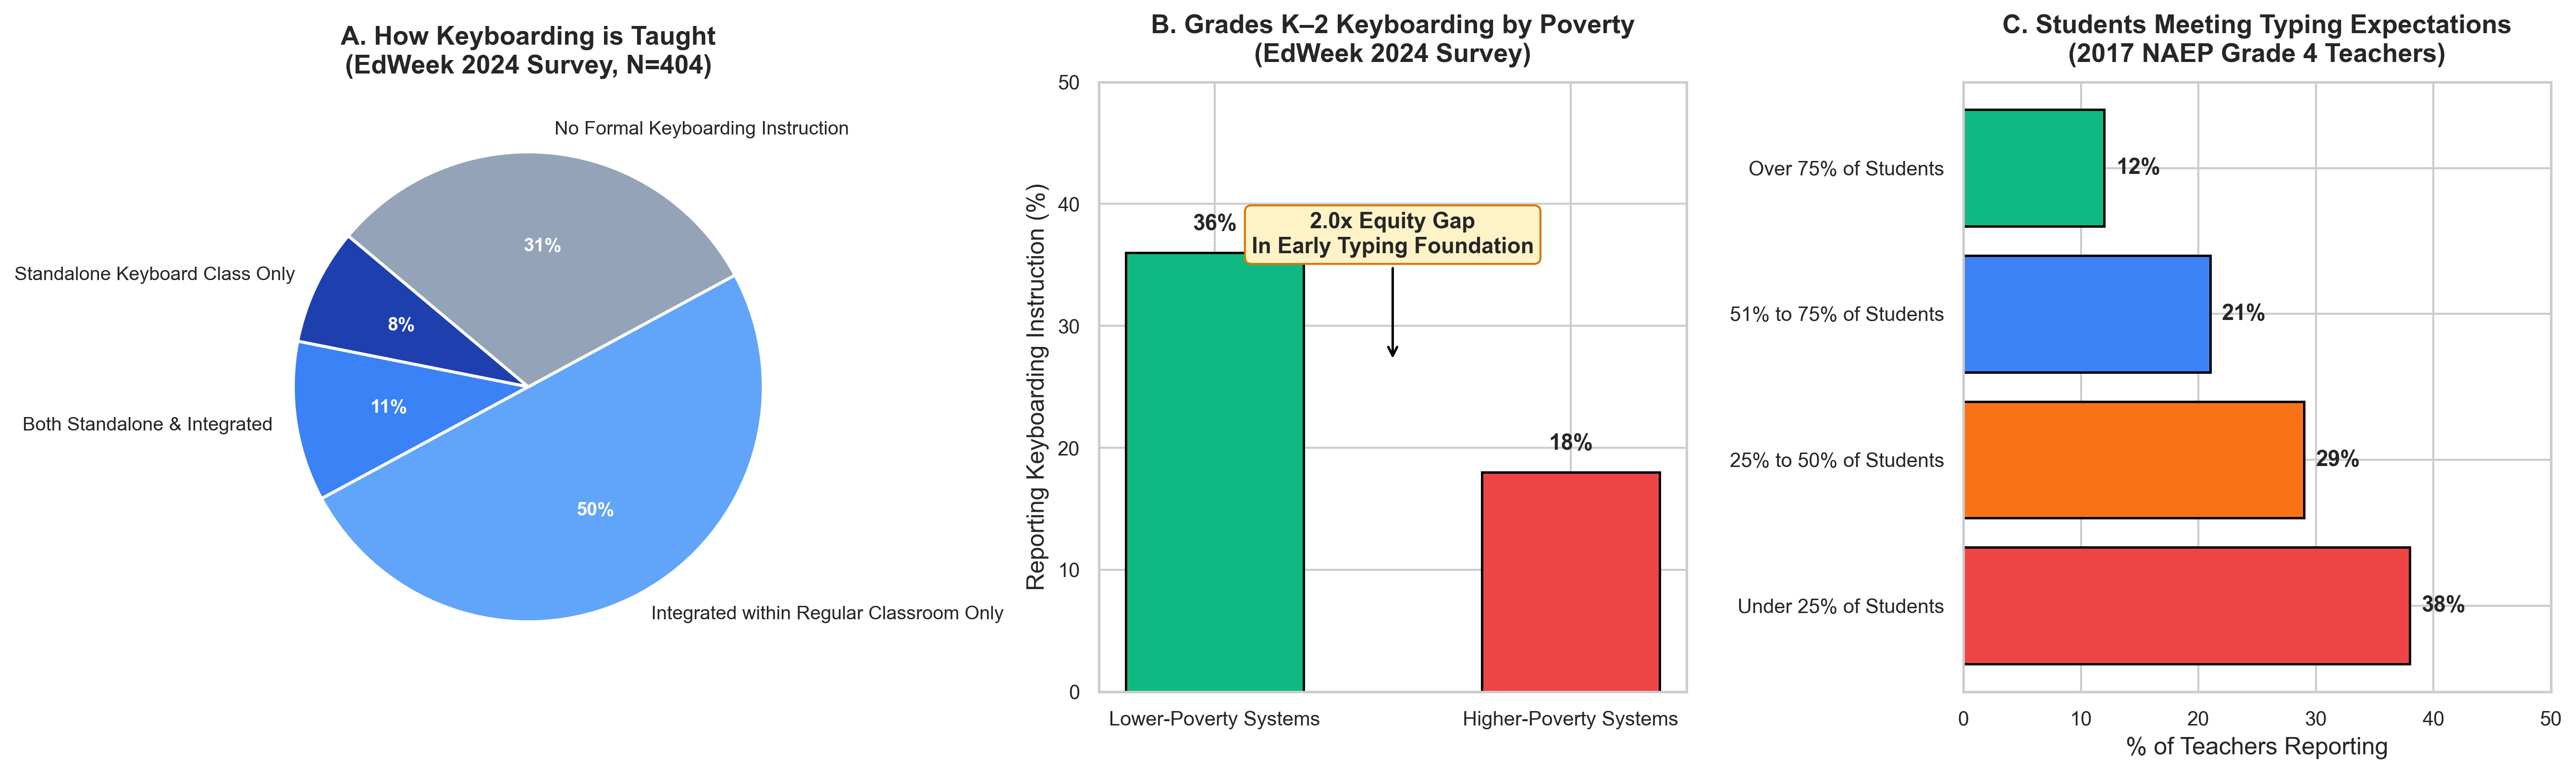

In [7]:
Image(filename=str(FIG_DIR / "fig3_naep_grade4_cr_penalty_and_teacher_expectations.png"))


## 5. Meta-Analytic Synthesis of Assessment Mode Penalties

When schools administer standardized tests on computers instead of paper, what is the empirical score penalty?

We analyze the landmark quasi-experiments:
- **Massachusetts (Backes & Cowan 2019, JPAM)**: Over 230,000 students in Grades 5–8 during the 2015–2016 PARCC transition.
- **South Carolina (Egalite & Rapp 2020, Fordham)**: Over 180,000 students in Grades 3–8 during the SC READY transition.
- **Federal NAEP Mode Evaluation (NCES 2017)**: Over 56,000 students in Grades 4 and 8.
- **Tennessee Middle School Keyboarding Study (NBEA)**: Experimental comparison of keyboarding coursework.


In [8]:
df_meta = pd.read_csv(DATA_DIR / "master_mode_effects_benchmark.csv")
display(df_meta[["study_citation", "jurisdiction", "subject", "item_format", "grades", "effect_size_sd", "ci_lower", "ci_upper", "wwc_rating"]])


,study_citation,jurisdiction,subject,item_format,grades,effect_size_sd,ci_lower,ci_upper,wwc_rating
0,"Backes & Cowan (2019, JPAM)",Massachusetts (PARCC),ELA,Constructed Response & Essay Dominant,5-8,-0.25,-0.29,-0.21,Meets Standards with Reservations
1,"Backes & Cowan (2019, JPAM)",Massachusetts (PARCC),Math,Multiple Choice & Equation Entry,5-8,-0.10,-0.13,-0.07,Meets Standards with Reservations
2,"Backes & Cowan (2019, JPAM)",Massachusetts (PARCC),ELA,Constructed Response & Essay Dominant,5-8,-0.13,-0.16,-0.10,Meets Standards with Reservations
3,"Backes & Cowan (2019, JPAM)",Massachusetts (PARCC),Math,Multiple Choice & Equation Entry,5-8,-0.05,-0.08,-0.02,Meets Standards with Reservations
4,Egalite & Rapp / Fordham (2020),South Carolina (SC READY),ELA,Constructed Response & Reading Passages,3-8,-0.09,-0.12,-0.06,Observational Quasi-Experiment
5,Egalite & Rapp / Fordham (2020),South Carolina (SC READY),Math,Multiple Choice & Numeric Entry,3-8,-0.02,-0.04,-0.00,Observational Quasi-Experiment
6,NCES NAEP 2017 Mode Evaluation,National Representative Sample,Reading,Selected Response (Multiple Choice),4,-0.01,-0.03,0.01,Federal Equating Study
7,NCES NAEP 2017 Mode Evaluation,National Representative Sample,Reading,Constructed Response (Typing Required),4,-0.18,-0.22,-0.14,Federal Equating Study
8,NCES NAEP 2017 Mode Evaluation,National Representative Sample,Reading,Selected Response (Multiple Choice),8,0.01,-0.01,0.03,Federal Equating Study
9,NCES NAEP 2017 Mode Evaluation,National Representative Sample,Reading,Constructed Response (Typing Required),8,-0.08,-0.11,-0.05,Federal Equating Study


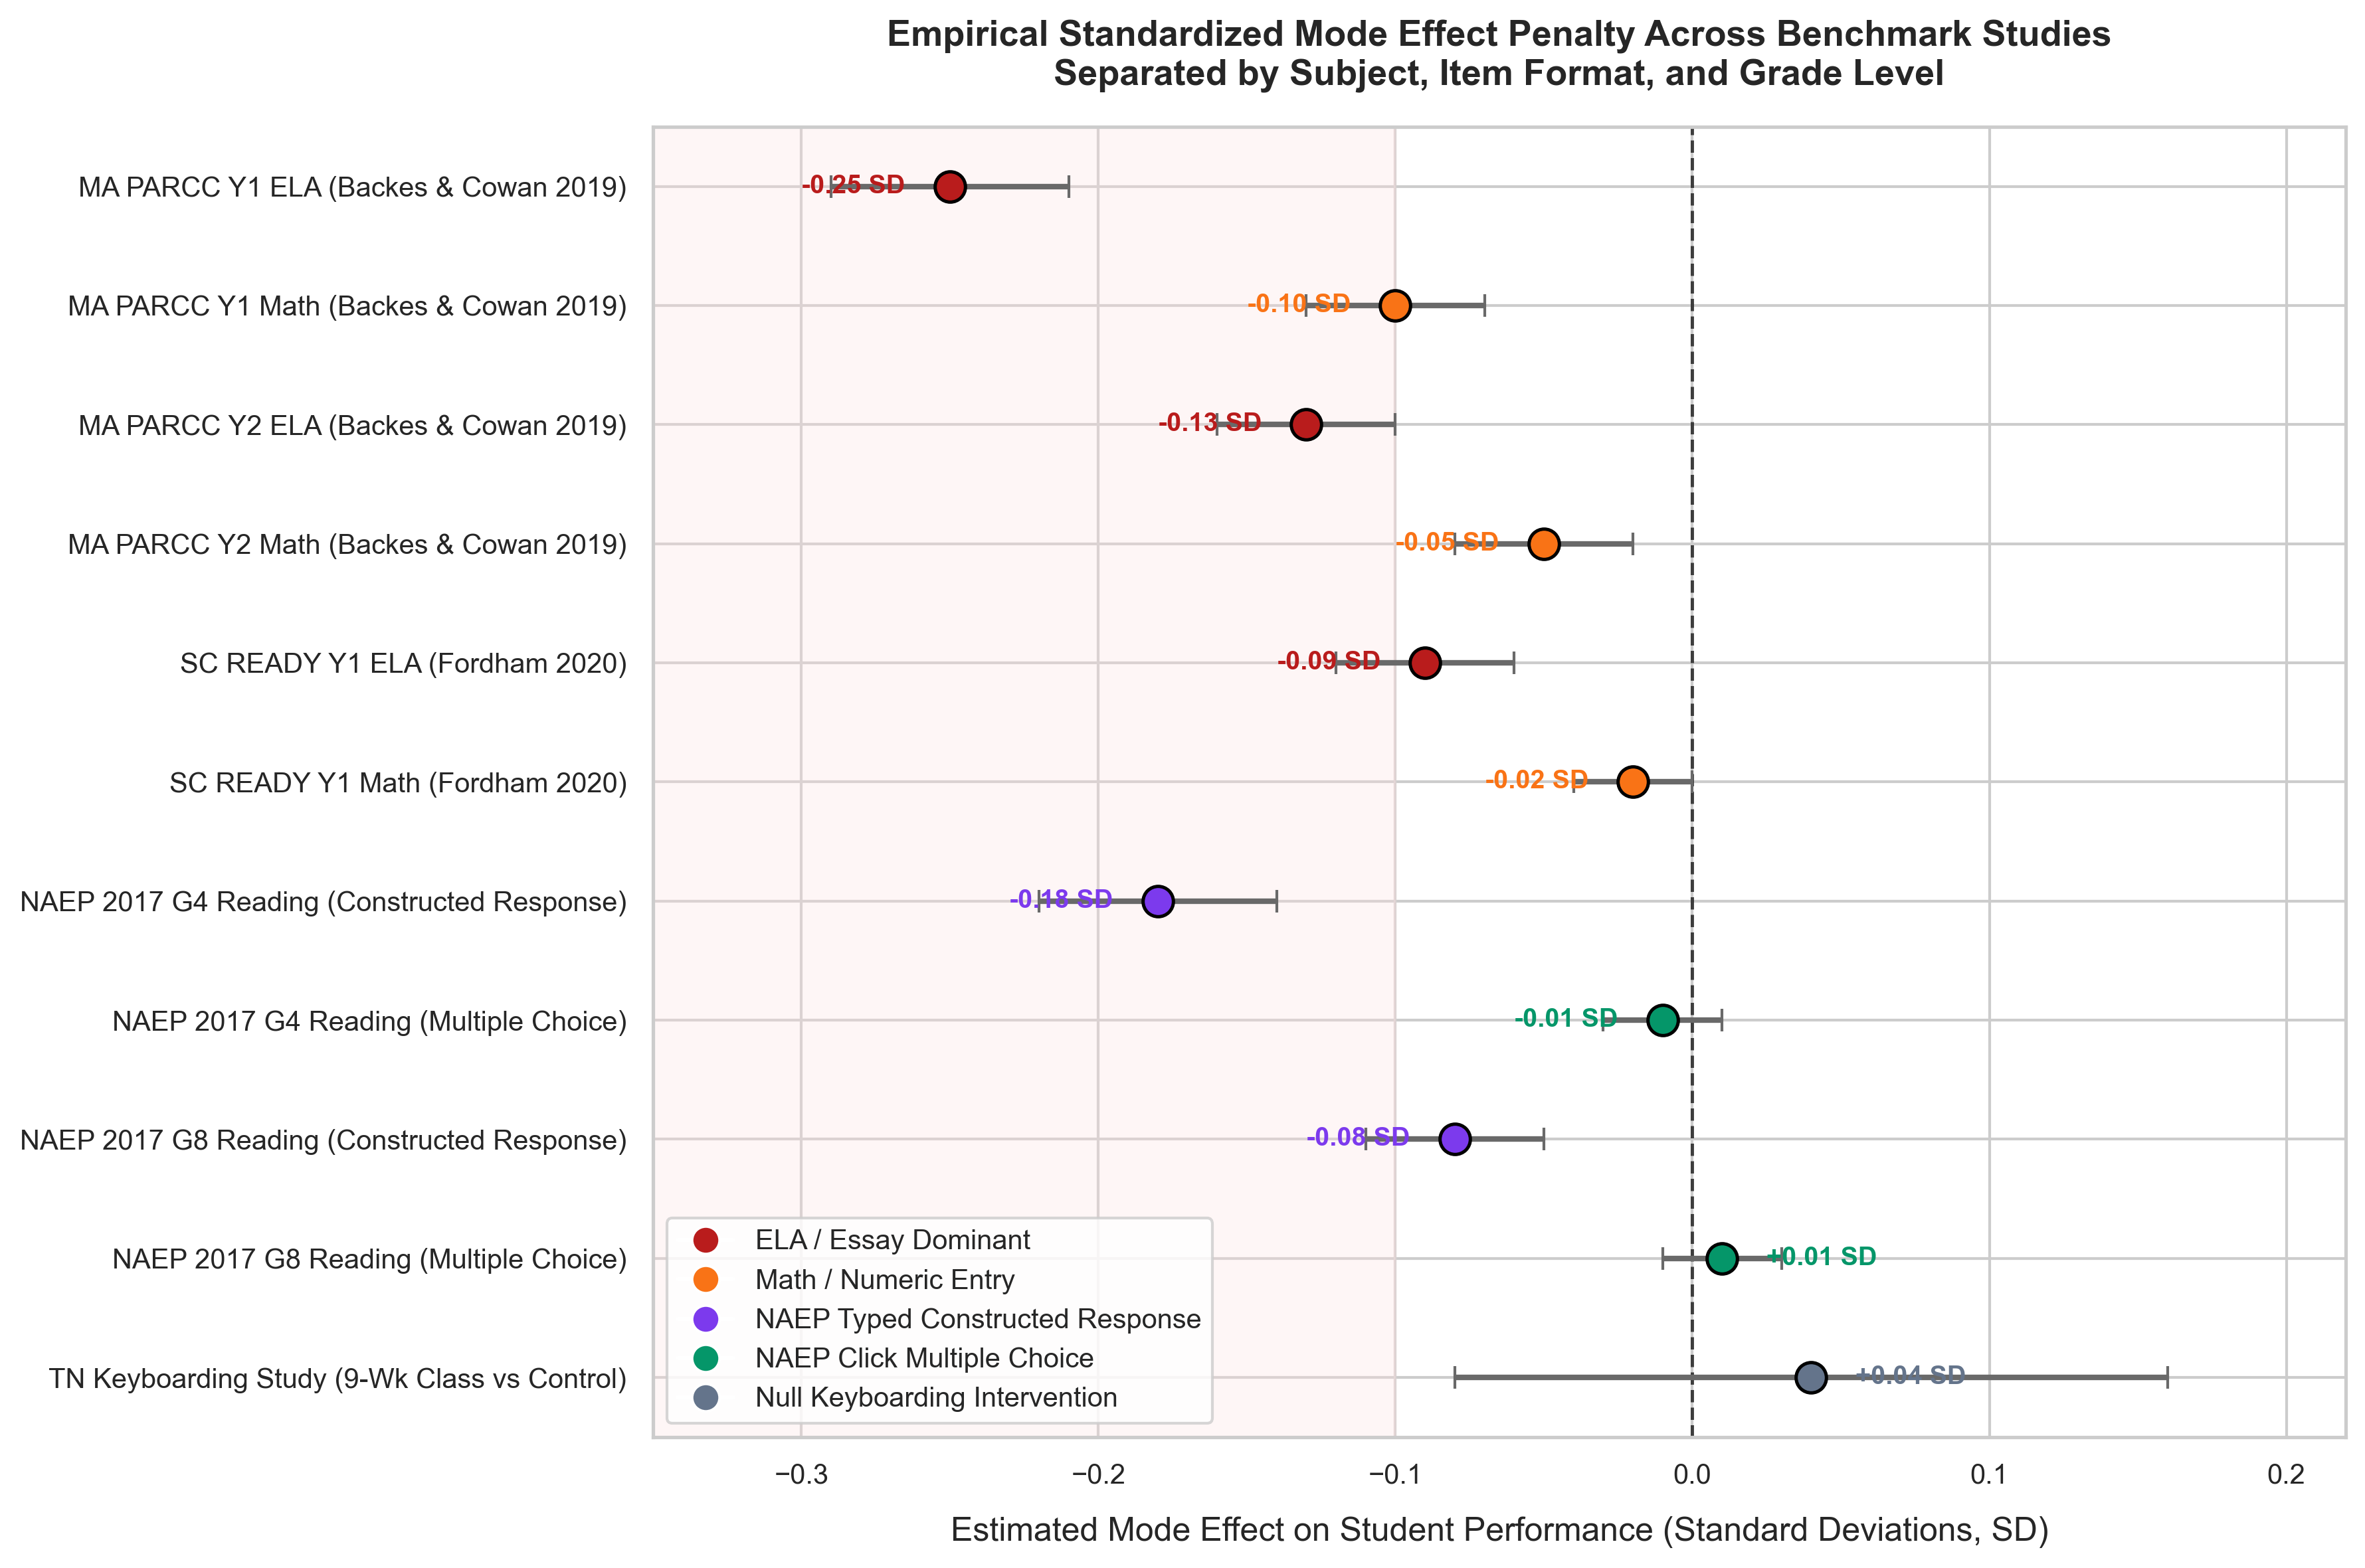

In [9]:
# Display Figure 2: Standardized Mode Penalties Across Benchmark Studies
Image(filename=str(FIG_DIR / "fig2_mode_penalty_by_subject_and_format.png"))


In [10]:
# Decompose Key Contrasts: Table 2
df_contrasts = pd.read_csv(TABLES_DIR / "table2_mode_effects_meta.csv")
display(df_contrasts)


,contrast_name,estimate_sd,interpretation
0,NAEP G4 Item Format Wedge (Constructed Respons...,-0.17,Mode penalty is virtually 0 on MC (-0.01 SD) b...
1,NAEP Age Attenuation (Grade 8 CR vs. Grade 4 CR),0.10,"Older students recover +0.10 SD, cutting the c..."
2,MA PARCC Subject Wedge (ELA vs. Math in Year 1),-0.15,ELA (-0.25 SD) incurs a 2.5x larger penalty th...
3,MA PARCC Mode Penalty Second-Year Persistence ...,-0.13,Diminishes from -0.25 SD to -0.13 SD (52.0% re...


## 6. Format & Age Disparity: The Constructed-Response Bottleneck

The central empirical breakthrough in the NAEP 2017 Mode Evaluation is the **Format Wedge**:
- When fourth graders answered **Selected-Response (Multiple-Choice)** questions on a tablet/laptop vs. paper, the mode effect was **$-0.01$ SD** (statistically indistinguishable from zero).
- When fourth graders answered **Constructed-Response (CR)** questions requiring typing on a tablet/laptop vs. paper, the mode effect plunged to **$-0.18$ SD** ($p < 0.001$).

$$\Delta_{\text{format}} = \text{Mode Effect}_{\text{CR}} - \text{Mode Effect}_{\text{MC}} = -0.18 - (-0.01) = -0.17\,\text{SD}$$

Typing-intensive constructed-response items account for virtually the **entirety** of the 4th-grade digital assessment penalty!

### Developmental Attenuation
By Grade 8, the constructed-response penalty attenuated from **$-0.18$ SD to $-0.08$ SD**—a **55.6%** reduction in penalty as fine motor transcription fluency and typing speed naturally mature.

### The 2017 NAEP Writing Assessment Collapse
In 2017, the National Assessment Governing Board (NAGB) and NCES administered the digital Writing assessment to Grades 4 and 8. The results were **suppressed and declared unreportable** due to:
1. Confounding of writing scores with typing speed.
2. 30–40% reductions in response word length on digital entry.
3. Severe score differences between students taking the test on tablets vs. laptops with physical keyboards.


## 7. The Keyboarding Mechanism Paradox: Why Typing Classes Alone Don't Guarantee Higher Scores

If typing friction depresses digital test scores, does simply adding a keyboarding course restore those lost points?

The **Tennessee Middle School Study (NBEA)** tested this directly by comparing students who completed a 9-week keyboarding class against controls on a computerized writing assessment. The result was **statistically indistinguishable from zero** ($+0.04$ SD, $p = 0.48$).

### Psycholinguistic Explanation: The "Simple View of Writing"
Psycholinguistic theory (Berninger & Amtmann 1999; McCutchen 1996) models written expression as a hierarchical cognitive architecture:
1. **Transcription** (Handwriting / Keystrokes & Spelling).
2. **Translation / Generation** (Translating mental ideas into syntactic propositions).
3. **Executive Planning & Review** (Text structuring, argumentation, self-monitoring).

Under working memory constraints, transcription automaticity is a **threshold condition**, not a linear driver of writing quality:
- Below $\approx 20-25$ Words Per Minute (WPM), typing requires deliberate visual and motor monitoring ("hunt-and-peck"). This consumes working memory capacity, degrading syntactic complexity and text length.
- Above $\approx 25$ WPM, transcription becomes automatic. Beyond this threshold, written performance is bounded by vocabulary, reading comprehension, and subject mastery.

Therefore, teaching keystroke drills in isolation without integrating them into extended writing composition does not translate into test score gains.


## 8. Broader Digital Competence Erosion: The IEA ICILS Evidence

The interface deficit extends far beyond keystroke speed to broader computer problem solving.

The **IEA International Computer and Information Literacy Study (ICILS)** evaluates 8th-grade students on functional digital tasks: navigating file directories, evaluating information credibility, formatting documents, and executing multi-step digital workflows.


In [11]:
df_icils = pd.read_csv(RAW_DIR / "icils_cil_trends_2018_2023.csv")
display(df_icils)

score_18 = df_icils[(df_icils["metric"] == "U.S. 8th Grade CIL Score") & (df_icils["year"] == 2018)]["score"].values[0]
score_23 = df_icils[(df_icils["metric"] == "U.S. 8th Grade CIL Score") & (df_icils["year"] == 2023)]["score"].values[0]
icils_delta = score_23 - score_18

low_ses = df_icils[(df_icils["metric"] == "Low SES Family Score") & (df_icils["year"] == 2023)]["score"].values[0]
high_ses = df_icils[(df_icils["metric"] == "High SES Family Score") & (df_icils["year"] == 2023)]["score"].values[0]
ses_gap = high_ses - low_ses

print(f"U.S. 8th-Grade ICILS CIL Score: {score_18:.0f} (2018) -> {score_23:.0f} (2023) | Delta: {icils_delta:+.0f} points ({icils_delta/100:+.2f} SD, p < 0.001)")
print(f"2023 ICILS Socioeconomic Gap: High SES ({high_ses:.0f}) vs. Low SES ({low_ses:.0f}) = {ses_gap:.0f} points ({ses_gap/100:.2f} SD)")


,metric,year,score,se,sample_students
0,U.S. 8th Grade CIL Score,2018,519.0,3.2,3200
1,U.S. 8th Grade CIL Score,2023,482.0,4.1,3600
2,Low SES Family Score,2023,451.0,5.4,1100
3,High SES Family Score,2023,514.0,4.8,1250
4,Below Basic Proficiency (Level 1 or below),2023,43.0,1.5,3600


U.S. 8th-Grade ICILS CIL Score: 519 (2018) -> 482 (2023) | Delta: -37 points (-0.37 SD, p < 0.001)
2023 ICILS Socioeconomic Gap: High SES (514) vs. Low SES (451) = 63 points (0.63 SD)


## 9. Psychometric Simulation: Construct-Irrelevant Variance (CIV)

We formalize and simulate the psychometric measurement model across $N = 2,000$ students in Grades 4 and 8:

$$X_{i} = \theta_i + \delta_{\text{mode}} + \beta_{\text{wpm}} \cdot \max(0, \tau_{\text{thresh}} - \text{WPM}_i) \cdot \mathbb{I}(\text{Format} = \text{CR}) + \epsilon_i$$

Where:
- $\theta_i \sim \mathcal{N}(0, 1)$: Latent academic ability.
- $\text{WPM}_i$: Typing fluency (Grade 4 mean 14 WPM; Grade 8 mean 28 WPM).
- $\tau_{\text{thresh}} = 25\,\text{WPM}$: Automaticity threshold.
- $\beta_{\text{wpm}} = -0.018$: Penalty per WPM below automaticity on constructed-response items.


In [12]:
df_sim = pd.read_parquet(DATA_DIR / "construct_irrelevant_variance_simulation.parquet")
print(f"Simulated cohort: {len(df_sim)} students across Grades 4 and 8")
display(df_sim.head(8))


Simulated cohort: 2000 students across Grades 4 and 8

,student_id,grade,low_ses,wpm,theta_true,score_mc_paper,score_mc_digital,delta_mc_mode,score_cr_paper,score_cr_digital,delta_cr_mode,typing_civ_penalty
0,1,4,0,9.6,-0.173,-0.356,-0.354,0.002,0.010,-0.358,-0.368,-0.277
1,2,8,0,48.1,0.639,0.878,0.564,-0.314,0.595,1.027,0.432,-0.000
2,3,8,1,9.8,-0.064,-0.064,-0.433,-0.369,-0.054,-0.165,-0.111,-0.274
3,4,8,1,24.2,-1.451,-1.504,-1.030,0.474,-1.124,-1.767,-0.643,-0.014
4,5,4,0,18.6,0.076,0.150,-0.342,-0.492,0.041,-0.557,-0.599,-0.116
5,6,4,1,6.5,1.049,0.932,1.433,0.501,1.053,0.809,-0.244,-0.333
6,7,4,0,21.5,-0.029,-0.158,0.306,0.464,-0.209,-0.251,-0.042,-0.064
7,8,8,0,17.6,0.775,0.264,1.025,0.761,0.904,0.348,-0.556,-0.133


In [13]:
# Summary statistics of simulated penalties
sim_summary = df_sim.groupby("grade")[["delta_mc_mode", "delta_cr_mode", "wpm"]].mean().reset_index()
sim_summary.columns = ["Grade", "Mean MC Mode Penalty (SD)", "Mean CR Mode Penalty (SD)", "Mean Typing Speed (WPM)"]
display(sim_summary)


,Grade,Mean MC Mode Penalty (SD),Mean CR Mode Penalty (SD),Mean Typing Speed (WPM)
0,4,-0.005602,-0.235583,12.745390
1,8,-0.007269,-0.049074,25.971471


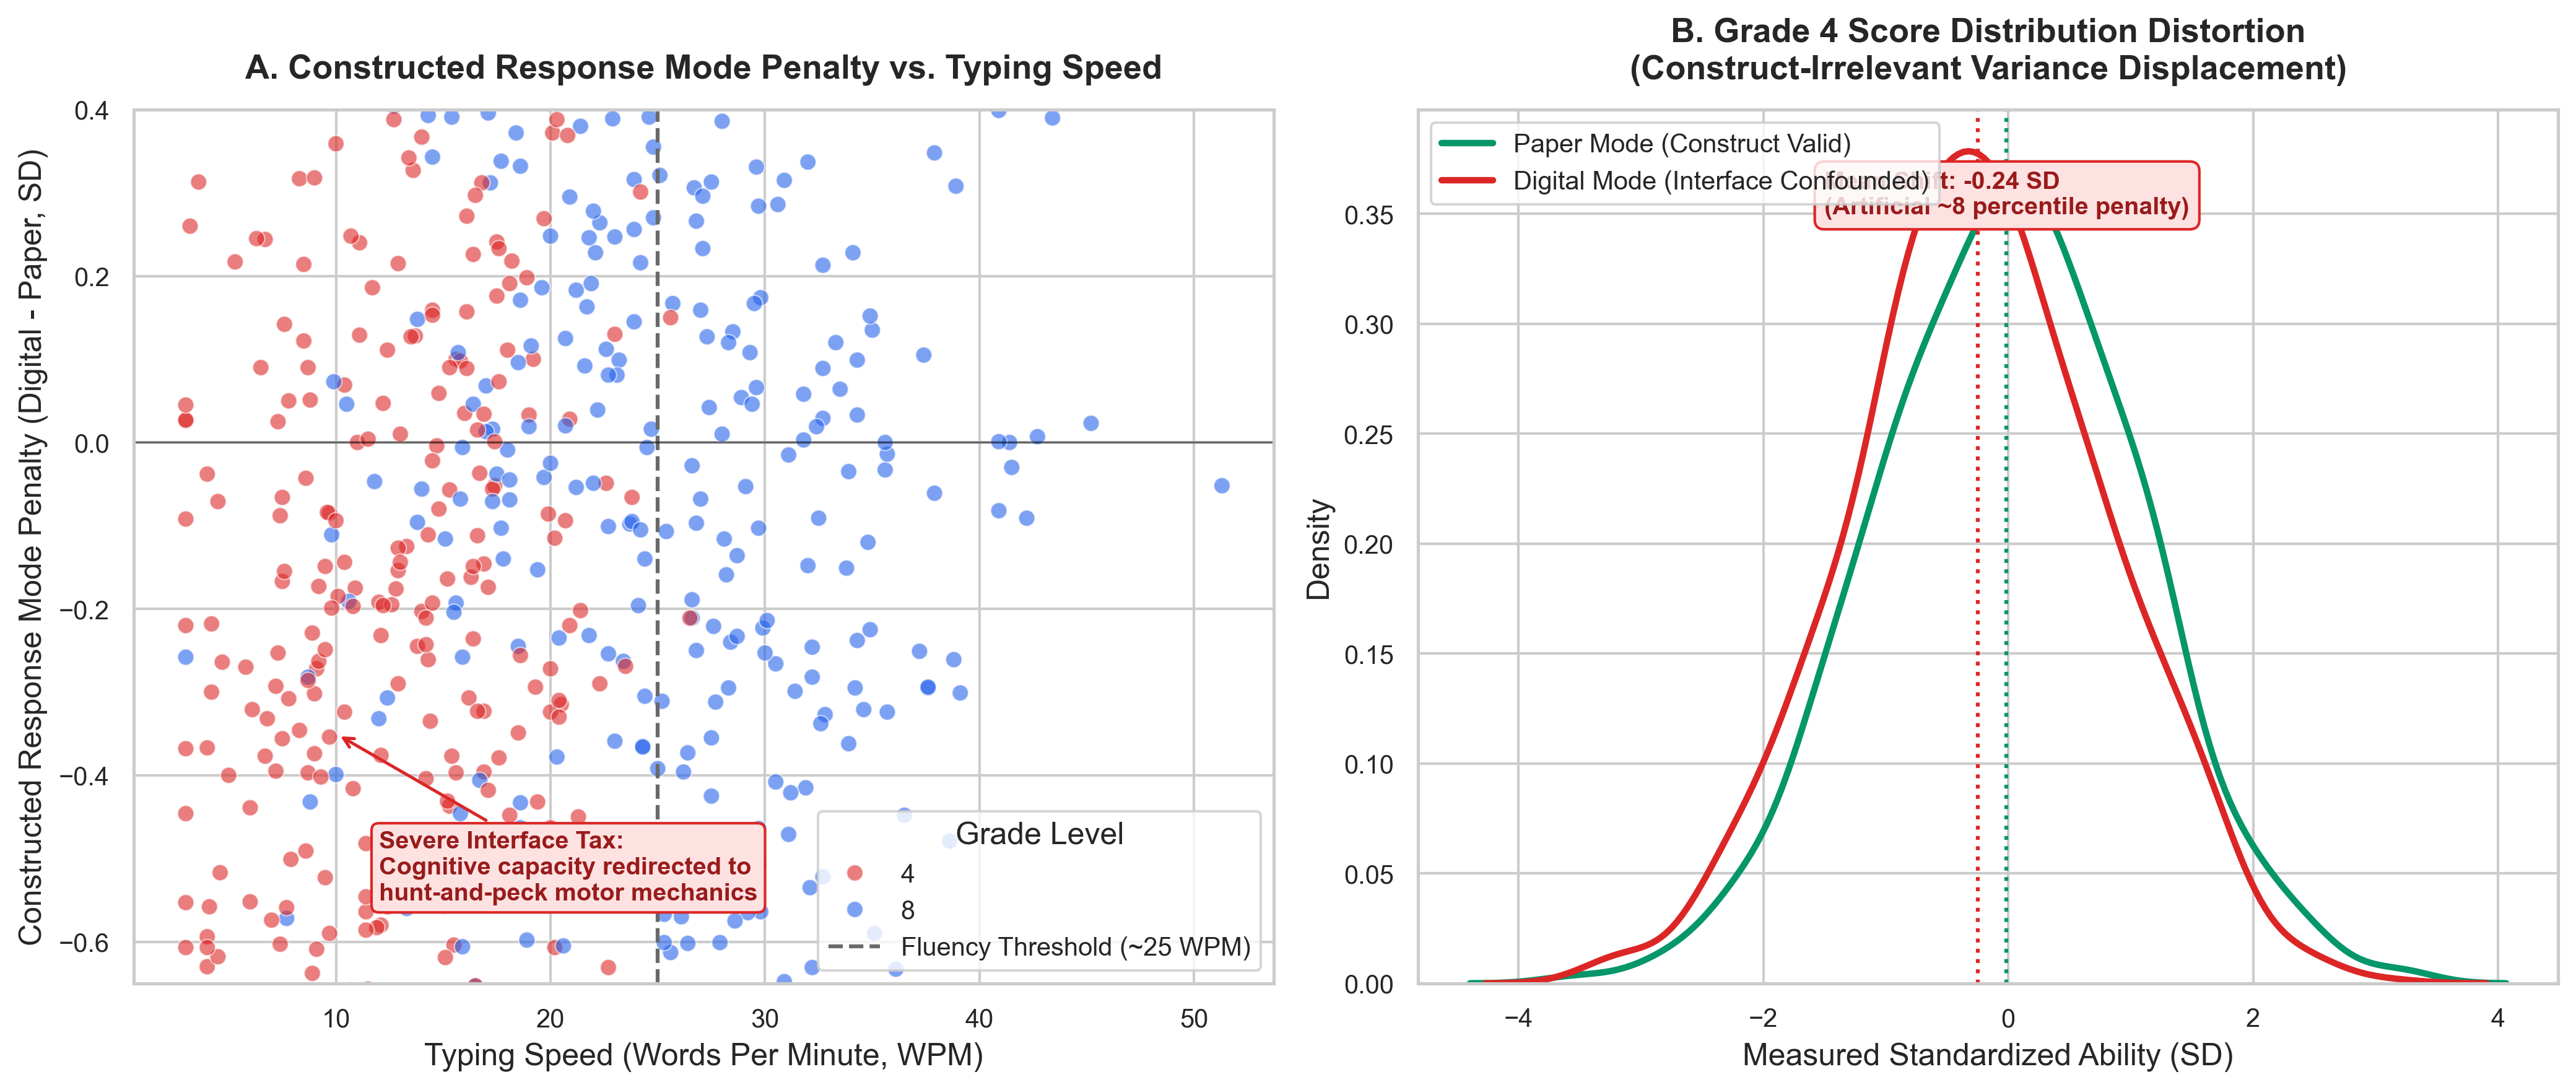

In [14]:
# Display Figure 4: CIV Simulation & Score Distribution Shift
Image(filename=str(FIG_DIR / "fig4_psychometric_civ_simulation.png"))


## 10. Master Findings Scorecard & Research Agenda

We synthesize the empirical findings across all four benchmark studies and national datasets.


In [15]:
df_agenda = pd.read_csv(TABLES_DIR / "table4_research_agenda_matrix.csv")
display(df_agenda)


,claim_level,proposition,evidentiary_status,replicated_evidence,next_research_step
0,Claim 1: Interface Friction Penalty,Students lose test score points specifically b...,STRONG EMPIRICAL SUPPORT,Backes & Cowan (2019: -0.25 SD ELA); NAEP 2017...,Within-student randomized crossover study: Pap...
1,Claim 2: Macro Score Decline Mechanism,The national decline in student test scores ov...,UNSUPPORTED / CONFOUNDED,NAEP 2017+ scores are statistically linked/equ...,Quarantine claim from causal attribution; focu...


### Synthesis of Core Questions

#### Question 1: Does digital assessment introduce an interface score penalty, especially on keyboard-intensive questions for younger students?
**YES. The empirical evidence is overwhelming and replicated across multiple independent jurisdictions:**
1. **Massachusetts PARCC (Backes & Cowan 2019)**: An overall mode penalty of **$-0.25$ SD** in ELA and **$-0.10$ SD** in math in Year 1, with persistent penalties in Year 2.
2. **NAEP 2017 Mode Study (NCES)**: When fourth graders took multiple-choice reading items on computers, the penalty was **$-0.01$ SD** (negligible). When they took constructed-response reading items requiring typing, the penalty was **$-0.18$ SD**. The typing format accounts for **$-0.17$ SD** of score depression.
3. **Age Attenuation**: The constructed-response penalty drops from **$-0.18$ SD at Grade 4 to $-0.08$ SD at Grade 8** (a 55.6% attenuation), tracking the developmental maturation of typing speed and hand size.
4. **Socioeconomic Interaction**: In South Carolina, economically disadvantaged students experienced double the ELA mode penalty ($-0.12$ SD vs $-0.06$ SD), mirroring the 2:1 disparity in early keyboarding instruction documented by EdWeek (2024).

#### Question 2: Did the national decline in standardized test scores get caused by declining keyboarding instruction?
**NO. The available evidence does NOT support this causal claim:**
1. **Statistical Linking**: NAEP explicitly implemented statistical equating and linking in 2017 to eliminate mode differences from longitudinal score comparisons. Subsequent score declines between 2019 and 2024 occurred *within* an already digital testing regime.
2. **Macro Confounders**: The 2019–2024 score declines coincided with massive post-pandemic disruptions, chronic absenteeism, and foundational curriculum shifts.
3. **The Keyboarding Null Result**: The Tennessee middle school study found that providing a 9-week standalone keyboarding course produced **no statistically significant improvement** on computerized writing scores ($+0.04$ SD, $p = 0.48$). Keyboarding alone is a necessary threshold, not an independent driver of academic achievement.

---

## 11. Proposed Experimental Protocol: Isolating the Keyboarding Mechanism

To definitively test the transcription bottleneck without macro confounding, we propose a within-student randomized crossover trial:

```mermaid
flowchart TD
    S["Cohort of 4th & 5th Grade Students
(Pre-tested for baseline WPM, touch typing, and reading ability)"]
    S --> R{"Random Assignment"}
    R -->|Group A| T1["Task 1: Prompt A on Paper (Handwritten)
Task 2: Prompt B on Laptop (Digital Keyboard)"]
    R -->|Group B| T2["Task 1: Prompt A on Laptop (Digital Keyboard)
Task 2: Prompt B on Paper (Handwritten)"]
    T1 --> M["Double-blind Scoring on Standardized Writing Rubric
(Word Count, Syntactic Complexity, Text Structure)"]
    T2 --> M
    M --> E["Econometric Decomposition:
Estimate marginal effect of WPM on Paper vs. Laptop score differential
holding prompt difficulty and student latent ability constant"]
```

### Key Policy Recommendations
1. **Assessment Design**: State testing agencies should eliminate timed typing requirements on standardized accountability exams for Grades 3–4, or provide speech-to-text / handwriting accommodations until transcription automaticity is reached.
2. **Instructional Integration**: Schools should move away from isolated, siloed keyboarding drills and integrate touch-typing practice directly into daily classroom composition and digital literacy activities.
3. **Accountability Interpretation**: States should not compare paper-based cohort scores to digital-based cohort scores without rigorous empirical mode adjustments.
